In [1]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain
import bisect
from collections import defaultdict

seed = 0

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'wikipedia'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/wikipedia/ml_wikipedia.csv


,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2,8229,36.0,0.0,2
2,2,8229,77.0,0.0,3
3,3,8230,131.0,0.0,4
4,2,8229,150.0,0.0,5


In [2]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [3]:
# sparsification 
sprs_type = 'ts_tpr_remove_MSS'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
sprs_df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True)
sprs_df.head()

,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2181,8735,429397.0,0.0,20857
2,2198,8735,433126.0,0.0,21023
3,2206,8536,434533.0,0.0,21107
4,2208,8575,435199.0,0.0,21134


In [4]:
def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

class Old_TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200):
        self.original_graph = original_graph
        self.seed=seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.initialize_kde()
        self.initialize_kd_tree()

    def initialize_kde(self):
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        self.kde = stats.gaussian_kde(inter_event_times)
        # Set the random state for KDE
        # self.kde.set_bandwidth(bw_method=self.kde.factor)
        # self.kde.reseed(self.seed)

    def initialize_kd_tree(self):
        self.temporal_kd_tree = cKDTree(self.original_graph['ts'].values.reshape(-1, 1))

    def assign_timestamps(self, num_samples):
        kde_samples = self.kde.resample(num_samples, self.rng)[0]
        cumulative_times = np.cumsum(kde_samples) + self.min_time
        cumulative_times = np.clip(cumulative_times, self.min_time, self.max_time)
        jitter = self.rng.uniform(0, self.time_window * 0.1, num_samples)
        sampled_timestamps = cumulative_times + jitter
        sampled_timestamps.sort()
        sampled_timestamps = np.clip(sampled_timestamps, self.min_time, self.max_time)
        return sampled_timestamps

    def find_next_events(self, timestamps):
        _, indices = self.temporal_kd_tree.query(timestamps.reshape(-1, 1), k=1)
        return self.original_graph['ts'].values[indices]

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [5]:
class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=100, min_activity_threshold=2):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        self.kde = stats.gaussian_kde(
            inter_event_times,
            bw_method=np.mean(self.bandwidths)
        )
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

## Basic

In [44]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[2]
early_df = orig_df[(orig_df['ts'] > early_start_time )& (orig_df['ts'] < early_end_time)]
src_nodes_degrees = Counter(early_df['u'])
dst_nodes_degrees = Counter(early_df['i'])

In [45]:
removed_edges = early_df[['u', 'i']].values.tolist()
print(len(removed_edges))
removed_edges = {tuple(edge) for edge in removed_edges}
print(len(removed_edges))
timestamps = early_df[['ts']].values.tolist()
# removed_edges

21021
3512


In [46]:
generated_simple_graphs = nx.bipartite.havel_hakimi_graph(aseq=list(src_nodes_degrees.values()),
                                                          bseq=list(dst_nodes_degrees.values()),
                                                          create_using=nx.Graph())
generated_edges = generated_simple_graphs.edges()

# Initialize TemporalSampler
sampler = TemporalSampler(early_df, time_window=1200, seed=seed)

# Generate timestamps for all potential negative samples
num_samples = len(generated_edges)
sampled_timestamps = sampler.assign_timestamps(num_samples)
len(generated_edges), len(sampled_timestamps)

(21021, 21021)

In [47]:
n = len(src_nodes_degrees)
degrees = dict(generated_simple_graphs.degree())
degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

src_mapping = create_node_mapping(src_nodes_degrees, degrees_top)
dst_mapping = create_node_mapping(dst_nodes_degrees, degrees_bottom)

len(src_mapping), len(dst_mapping)

(2196, 656)

In [48]:
from itertools import product

df_sorted =early_df.sort_values('ts')
original_edges = set(tuple(x) for x in early_df[['u', 'i']].values)

min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

map_ts_to_edges = {}

# map_edges_to_ts = {}
map_edges_to_ts = defaultdict(list)

for timestamp in tqdm(sampled_timestamps, desc='Processing'):
    nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, 1200)
    
    src_nodes_orig = [n for n in nodes_in_window if min_src <= n <= max_src]  
    dst_nodes_orig = [n for n in nodes_in_window if min_dst <= n < max_dst]
    
    edges = [edge
        for edge in product(src_nodes_orig, dst_nodes_orig)
        if edge not in original_edges
    ]
    
    # edges = [
    #     (u, v) for u in src_nodes_orig for v in dst_nodes_orig
    #     if (u, v) not in original_edges
    # ]
    
    # assert len(edges) > 0, f'No such edge for {timestamp = }'
    
    map_ts_to_edges[timestamp] = edges
    for edge in edges:
        if edge not in map_edges_to_ts.keys():
            map_edges_to_ts[edge] = []
        map_edges_to_ts[edge].append(timestamp)
    

Processing: 100%|██████████| 21021/21021 [00:17<00:00, 1210.73it/s]


In [ ]:
[ts for ts, edges in map_ts_to_edges.items() if len(edges) == 0]

In [49]:
feasible_edges_dict = deepcopy(map_edges_to_ts)
# sampled_timestamps

gen_edges = [(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in generated_edges]

degree_dict = deepcopy(src_nodes_degrees)
degree_dict.update(dst_nodes_degrees)

### New Attack

In [ ]:
from collections import defaultdict
from typing import Dict, List, Set, Tuple, Optional
import numpy as np
from tqdm import tqdm

class UnifiedEdgeRepopulator:
    def __init__(self, 
                 window_size: int,
                 timestamps: List[int],
                 feasible_edges_dict: Dict,
                 removed_edges: Set[Tuple[int, int]],
                 degree_dict: Dict[int, int],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Unified Edge Repopulator (handles both bipartite and non-bipartite)
        
        Args:
            window_size: Size of sliding window for C3
            timestamps: List of valid timestamps
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            removed_edges: Edges removed during sparsification
            degree_dict: Original node degrees
            src_nodes: Set of source nodes (for bipartite)
            dst_nodes: Set of destination nodes (for bipartite)
        """
        self.window_size = window_size
        self.timestamps = sorted(timestamps)  # Sort timestamps
        self.feasible_edges_dict = feasible_edges_dict
        self.removed_edges = removed_edges
        self.degree_dict = degree_dict
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        
        # Set up node sets based on graph type
        if self.is_bipartite:
            self.src_nodes = src_nodes
            self.dst_nodes = dst_nodes
            self.current_window_src = set()
            self.current_window_dst = set()
        else:
            self.current_window_nodes = set()
            
        self.perturbation_counts = defaultdict(int)
        self.new_edges = []
        self.window_edges = []
        
    def calculate_n(self, window_nodes: Set[int]) -> int:
        """Calculate N based on window nodes"""
        if self.is_bipartite:
            src_count = len(self.current_window_src)
            dst_count = len(self.current_window_dst)
            e_max = min(src_count, dst_count)
        else:
            e_max = len(window_nodes) // 2
            
        k = min(len(self.removed_edges), self.window_size)
        return np.ceil(k / max(1, e_max))
    
    def update_window(self, new_edge: Tuple[int, int, int]):
        """Update window tracking based on graph type"""
        self.window_edges.append(new_edge)
        
        # Remove old edges if window full
        while len(self.window_edges) > self.window_size:
            old_edge = self.window_edges.pop(0)
            if self.is_bipartite:
                # Update bipartite window sets
                self._update_bipartite_window()
            else:
                # Update regular window set
                self._update_regular_window()
                
        # Add new nodes
        u, v, _ = new_edge
        if self.is_bipartite:
            if u in self.src_nodes:
                self.current_window_src.add(u)
                self.current_window_dst.add(v)
            else:
                self.current_window_src.add(v)
                self.current_window_dst.add(u)
        else:
            self.current_window_nodes.update({u, v})
            
    def _update_bipartite_window(self):
        """Update bipartite window sets"""
        self.current_window_src.clear()
        self.current_window_dst.clear()
        for e in self.window_edges:
            u, v, _ = e
            if u in self.src_nodes:
                self.current_window_src.add(u)
                self.current_window_dst.add(v)
            else:
                self.current_window_src.add(v)
                self.current_window_dst.add(u)
                
    def _update_regular_window(self):
        """Update regular window set"""
        self.current_window_nodes.clear()
        for e in self.window_edges:
            u, v, _ = e
            self.current_window_nodes.update({u, v})
            
    def get_candidate_edges(self, source_node: int) -> List[Tuple[int, int]]:
        """Get valid candidate edges based on graph type"""
        candidates = []
        n_limit = self.calculate_n(self.current_window_src if self.is_bipartite else self.current_window_nodes)
        
        if self.is_bipartite:
            target_nodes = (self.current_window_dst if source_node in self.src_nodes 
                          else self.current_window_src)
        else:
            target_nodes = self.current_window_nodes - {source_node}
            
        for target_node in target_nodes:
            edge = (source_node, target_node)
            if self.is_valid_candidate(edge, source_node, target_node, n_limit):
                candidates.append(edge)
                
        return candidates
    
    def is_valid_candidate(self, edge: Tuple[int, int], source: int, target: int, n_limit: float) -> bool:
        """Check if candidate edge is valid"""
        # Basic checks
        if edge in self.removed_edges:
            return False
        if self.perturbation_counts[target] >= n_limit:
            return False
        if edge not in self.feasible_edges_dict:
            return False
        if not self.feasible_edges_dict[edge]:
            return False
            
        # Bipartite specific check
        if self.is_bipartite:
            if source in self.src_nodes and target in self.src_nodes:
                return False
            if source in self.dst_nodes and target in self.dst_nodes:
                return False
                
        return True
    
    def select_best_edge(self, candidates: List[Tuple[int, int]]) -> Optional[Tuple[int, int, int]]:
        """Select best edge based on multiple criteria"""
        if not candidates:
            return None
            
        scored_candidates = []
        for edge in candidates:
            score = self.compute_edge_score(edge)
            scored_candidates.append((score, edge))
            
        scored_candidates.sort(reverse=True)
        best_edge = scored_candidates[0][1]
        
        # Select earliest feasible timestamp
        timestamps = sorted(self.feasible_edges_dict[best_edge])
        if timestamps:
            return (best_edge[0], best_edge[1], timestamps[0])
        return None
    
    def compute_edge_score(self, edge: Tuple[int, int]) -> float:
        """Compute score for candidate edge"""
        u, v = edge
        score = 0
        
        # Prioritize nodes based on original degree
        score += self.degree_dict[u] + self.degree_dict[v]
        
        # Penalize high perturbation counts
        score -= (self.perturbation_counts[u] + self.perturbation_counts[v]) * 10
        
        # Reward more feasible timestamps
        score += len(self.feasible_edges_dict[edge])
        
        return score
    
    def repopulate(self) -> List[Tuple[int, int, int]]:
        """Main repopulation algorithm"""
        print("Starting repopulation...")
        print(f"Graph type: {'Bipartite' if self.is_bipartite else 'Non-bipartite'}")
        
        # Initialize window with first batch of nodes
        self._initialize_window()
        
        for t in tqdm(self.timestamps, desc="Repopulating edges"):
            if self.is_bipartite:
                active_nodes = self.current_window_src
            else:
                active_nodes = self.current_window_nodes
                
            # Sort nodes by degree (higher degree first)
            nodes = sorted(active_nodes, 
                         key=lambda x: (self.degree_dict[x], -self.perturbation_counts[x]),
                         reverse=True)
            
            for source_node in nodes:
                n_limit = self.calculate_n(active_nodes)
                if self.perturbation_counts[source_node] >= n_limit:
                    continue
                    
                candidates = self.get_candidate_edges(source_node)
                best_edge = self.select_best_edge(candidates)
                
                if best_edge:
                    self.new_edges.append(best_edge)
                    self.perturbation_counts[best_edge[0]] += 1
                    self.perturbation_counts[best_edge[1]] += 1
                    self.update_window(best_edge)
        
        return self.new_edges
    
    def _initialize_window(self):
        """Initialize window with first batch of nodes from removed edges"""
        initial_edges = list(self.removed_edges)[:self.window_size]
        if self.is_bipartite:
            for u, v in initial_edges:
                if u in self.src_nodes:
                    self.current_window_src.add(u)
                    self.current_window_dst.add(v)
                else:
                    self.current_window_src.add(v)
                    self.current_window_dst.add(u)
        else:
            for u, v in initial_edges:
                self.current_window_nodes.update({u, v})

In [ ]:
# repopulator = UnifiedEdgeRepopulator(
#     window_size=1200,
#     timestamps=sampled_timestamps,
#     feasible_edges_dict=feasible_edges_dict,
#     removed_edges=removed_edges,
#     degree_dict=degree_dict,
#     src_nodes=set(src_nodes_degrees.keys()),
#     dst_nodes=set(dst_nodes_degrees.keys())
# )
# new_edges = repopulator.repopulate()

In [ ]:
from collections import defaultdict, deque
from typing import Dict, List, Set, Tuple, Optional
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import threading

class FastEdgeRepopulator:
    def __init__(self, 
                 window_size: int,
                 timestamps: List[int],
                 feasible_edges_dict: Dict,
                 removed_edges: Set[Tuple[int, int]],
                 degree_dict: Dict[int, int],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Optimized Edge Repopulator
        """
        self.window_size = window_size
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        
        # Convert inputs to efficient data structures
        self.timestamps = np.array(sorted(timestamps))
        self.removed_edges = set(removed_edges)
        self.degree_dict = degree_dict
        
        # Track total edges needed
        self.total_edges_needed = len(removed_edges)
        self.edges_generated = 0
        
        # Adjust batch size based on total edges needed
        self.batch_size = min(5000, max(1000, self.total_edges_needed // 10))
        
        # Pre-compute feasible edges data structures
        self.feasible_adj_lists = defaultdict(set)
        self.feasible_timestamps = {}
        for (u, v), ts_list in feasible_edges_dict.items():
            self.feasible_adj_lists[u].add(v)
            self.feasible_timestamps[(u, v)] = np.array(sorted(ts_list))
        
        # Initialize node sets
        if self.is_bipartite:
            self.src_nodes = set(src_nodes)
            self.dst_nodes = set(dst_nodes)
            self.current_window_src = set()
            self.current_window_dst = set()
        else:
            self.current_window_nodes = set()
            
        # Tracking structures
        self.window_edges = deque(maxlen=self.window_size)
        self.perturbation_counts = defaultdict(int)
        self.new_edges = []
        
        # Caching
        self._score_cache = {}
        self._lock = threading.Lock()
        
        # Initialize node degree priority
        self.node_priority = {
            node: (degree_dict[node], node) 
            for node in degree_dict
        }
        
        # Pre-calculate N for optimization
        self.n_limit = self._calculate_initial_n()
        
    def _calculate_initial_n(self) -> float:
        """Pre-calculate N based on initial conditions"""
        if self.is_bipartite:
            e_max = min(len(self.src_nodes), len(self.dst_nodes))
        else:
            e_max = len(self.degree_dict) // 2
        # k = min(len(self.removed_edges), self.window_size)
        k = self.total_edges_needed
        return np.ceil(k / max(1, e_max))

    def _fast_add_nodes(self, u: int, v: int):
        """Optimized node addition to window"""
        if self.is_bipartite:
            if u in self.src_nodes:
                self.current_window_src.add(u)
                self.current_window_dst.add(v)
            else:
                self.current_window_src.add(v)
                self.current_window_dst.add(u)
        else:
            self.current_window_nodes.update({u, v})
            
    def _fast_remove_nodes(self, u: int, v: int):
        """Optimized node removal from window"""
        if self.is_bipartite:
            if not any(e[0] == u or e[1] == u for e in self.window_edges):
                self.current_window_src.discard(u)
            if not any(e[0] == v or e[1] == v for e in self.window_edges):
                self.current_window_dst.discard(v)
        else:
            if not any(u in e[:2] for e in self.window_edges):
                self.current_window_nodes.discard(u)
            if not any(v in e[:2] for e in self.window_edges):
                self.current_window_nodes.discard(v)
                
    def update_window(self, new_edge: Tuple[int, int, int]):
        """Fast window update"""
        if len(self.window_edges) >= self.window_size:
            old_edge = self.window_edges[0]
            self._fast_remove_nodes(old_edge[0], old_edge[1])
            self.window_edges.popleft()
            
        self.window_edges.append(new_edge)
        self._fast_add_nodes(new_edge[0], new_edge[1])

    def get_candidate_edges(self, source_node: int) -> List[Tuple[int, int]]:
        """Optimized candidate generation"""
        if self.is_bipartite:
            if source_node in self.src_nodes:
                possible_targets = self.feasible_adj_lists[source_node] & self.current_window_dst
            else:
                possible_targets = {v for v in self.current_window_src 
                                  if source_node in self.feasible_adj_lists[v]}
        else:
            possible_targets = self.feasible_adj_lists[source_node] & self.current_window_nodes
            
        return [(source_node, v) for v in possible_targets 
                if self.is_valid_candidate_fast(source_node, v)]

    def is_valid_candidate_fast(self, source: int, target: int) -> bool:
        """Optimized candidate validation"""
        edge = (source, target)
        
        # Quick checks first
        if edge in self.removed_edges:
            return False
        if self.perturbation_counts[target] >= self.n_limit:
            return False
        if edge not in self.feasible_timestamps:
            return False
        if len(self.feasible_timestamps[edge]) == 0:
            return False
            
        # Bipartite check if needed
        if self.is_bipartite:
            if source in self.src_nodes and target in self.src_nodes:
                return False
            if source in self.dst_nodes and target in self.dst_nodes:
                return False
                
        return True

    def compute_edge_score(self, edge: Tuple[int, int]) -> float:
        """Optimized edge scoring with caching"""
        cache_key = edge
        if cache_key in self._score_cache:
            return self._score_cache[cache_key]
            
        u, v = edge
        # Prioritize based on degree and perturbation count
        score = (self.degree_dict[u] + self.degree_dict[v]) * 10
        score -= (self.perturbation_counts[u] + self.perturbation_counts[v]) * 100
        score += len(self.feasible_timestamps[edge])
        
        self._score_cache[cache_key] = score
        return score

    def old_process_batch(self, nodes: List[int], batch_timestamps: np.ndarray) -> List[Tuple[int, int, int]]:
        """Process a batch of nodes in parallel"""
        batch_edges = []
        
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = []
            for node in nodes:
                if self.perturbation_counts[node] >= self.n_limit:
                    continue
                futures.append(
                    executor.submit(self._process_node, node, batch_timestamps)
                )
            
            for future in futures:
                edge = future.result()
                if edge:
                    batch_edges.append(edge)
                    
        return batch_edges

    def _process_batch(self, nodes: List[int], batch_timestamps: np.ndarray) -> List[Tuple[int, int, int]]:
        """Process a batch of nodes in parallel"""
        batch_edges = []
        edges_needed = min(
            self.batch_size,
            self.total_edges_needed - self.edges_generated
        )
        
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = []
            for node in nodes:
                if len(futures) >= edges_needed:
                    break
                futures.append(
                    executor.submit(self._process_node, node, batch_timestamps)
                )
            
            for future in futures:
                edge = future.result()
                if edge:
                    batch_edges.append(edge)
                    
        return batch_edges
    
    def _process_node(self, node: int, batch_timestamps: np.ndarray) -> Optional[Tuple[int, int, int]]:
        """Process a single node"""
        candidates = self.get_candidate_edges(node)
        if not candidates:
            return None
            
        # Score and sort candidates
        scored_candidates = []
        for edge in candidates:
            score = self.compute_edge_score(edge)
            scored_candidates.append((score, edge))
            
        if not scored_candidates:
            return None
            
        scored_candidates.sort(reverse=True)
        best_edge = scored_candidates[0][1]
        
        # Find earliest valid timestamp in batch
        valid_timestamps = self.feasible_timestamps[best_edge]
        mask = np.isin(valid_timestamps, batch_timestamps)
        if not np.any(mask):
            return None
            
        timestamp = valid_timestamps[mask][0]
        return (best_edge[0], best_edge[1], timestamp)

    def Old_repopulate(self) -> List[Tuple[int, int, int]]:
        """Optimized main repopulation algorithm"""
        print("Starting fast repopulation...")
        
        # Initialize with first batch of nodes
        initial_edges = list(self.removed_edges)[:self.window_size]
        for u, v in initial_edges:
            self._fast_add_nodes(u, v)
        
        # Process in batches
        batch_size = min(1000, len(self.timestamps))
        for batch_start in tqdm(range(0, len(self.timestamps), batch_size)):
            batch_end = min(batch_start + batch_size, len(self.timestamps))
            batch_timestamps = self.timestamps[batch_start:batch_end]
            
            # Get active nodes for batch
            if self.is_bipartite:
                active_nodes = sorted(
                    self.current_window_src,
                    key=lambda x: (-self.degree_dict[x], self.perturbation_counts[x])
                )
            else:
                active_nodes = sorted(
                    self.current_window_nodes,
                    key=lambda x: (-self.degree_dict[x], self.perturbation_counts[x])
                )
            
            # Process batch
            batch_edges = self._process_batch(active_nodes, batch_timestamps)
            
            # Update structures
            with self._lock:
                for edge in batch_edges:
                    self.new_edges.append(edge)
                    self.perturbation_counts[edge[0]] += 1
                    self.perturbation_counts[edge[1]] += 1
                    self.update_window(edge)
                    
        return self.new_edges
    
    def repopulate(self) -> List[Tuple[int, int, int]]:
        """Optimized main repopulation algorithm"""
        print(f"New repopulate --> Starting repopulation... Target: {self.total_edges_needed} edges")
        
        # Initialize with first batch of nodes
        initial_edges = list(self.removed_edges)[:self.window_size]
        for u, v in initial_edges:
            self._fast_add_nodes(u, v)
        
        # Continue generating until we meet the target
        pbar = tqdm(total=self.total_edges_needed, desc="Generating edges")
        while self.edges_generated < self.total_edges_needed:
            # Get timestamps for this batch
            batch_start = (self.edges_generated % len(self.timestamps))
            batch_end = min(batch_start + self.batch_size, len(self.timestamps))
            batch_timestamps = self.timestamps[batch_start:batch_end]
            
            if batch_start >= batch_end:
                # Wrap around to start of timestamps if needed
                batch_timestamps = self.timestamps[:self.batch_size]
            
            # Get active nodes for batch
            if self.is_bipartite:
                active_nodes = sorted(
                    self.current_window_src,
                    key=lambda x: (-self.degree_dict[x], self.perturbation_counts[x])
                )
            else:
                active_nodes = sorted(
                    self.current_window_nodes,
                    key=lambda x: (-self.degree_dict[x], self.perturbation_counts[x])
                )
            
            # Process batch
            batch_edges = self._process_batch(active_nodes, batch_timestamps)
            
            # Update structures
            with self._lock:
                for edge in batch_edges:
                    self.new_edges.append(edge)
                    self.perturbation_counts[edge[0]] += 1
                    self.perturbation_counts[edge[1]] += 1
                    self.update_window(edge)
                    self.edges_generated += 1
                    pbar.update(1)
                    
                    if self.edges_generated >= self.total_edges_needed:
                        break
            
            # Break if we can't generate any more edges
            if not batch_edges:
                print("\nWarning: Cannot generate more edges. Stopping early.")
                break
                
        pbar.close()
        print(f"Generated {self.edges_generated} edges out of {self.total_edges_needed} target")
        return self.new_edges

In [ ]:
repopulator = FastEdgeRepopulator(
    window_size=1200,
    timestamps=sampled_timestamps,
    feasible_edges_dict=feasible_edges_dict,
    removed_edges=removed_edges,
    degree_dict=degree_dict,
    src_nodes=set(src_nodes_degrees.keys()),
    dst_nodes=set(dst_nodes_degrees.keys())
)
new_edges = repopulator.repopulate()

In [ ]:
# V1
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        self.feasible_edges_dict = feasible_edges_dict
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, 
                    edge: Tuple[int, int], 
                    timestamps: List[int]) -> bool:
        """Check if edge can be selected"""
        if not timestamps:
            return False
            
        u, v = edge
        if self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
            return False
            
        if self.is_bipartite:
            # Check bipartite constraint
            if u in self.src_nodes and v in self.src_nodes:
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                return False
                
        return True
        
    def _pick_best_timestamp(self, 
                           timestamps: List[int], 
                           edge: Tuple[int, int]) -> int:
        """Select best timestamp from available options"""
        # For now, simply take the earliest timestamp
        # Could be enhanced with more sophisticated selection
        return min(timestamps)
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm to select edge-timestamp pairs"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Sort nodes by degree for priority
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            # Skip if node has no remaining capacity
            if self.remaining_capacity[node] <= 0:
                continue
                
            # Get and process candidates while node has capacity
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                # Get candidate edges for current node
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                # Score candidates
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                # Sort by score
                scored_candidates.sort(reverse=True)
                
                # Try to select best candidate
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        
                        # Add selection and update tracking
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        # Validate and return results
        self._validate_selections()
        return self.selected_pairs

    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    

## BackAttack

In [ ]:
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        self.feasible_edges_dict = feasible_edges_dict
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, 
                    edge: Tuple[int, int], 
                    timestamps: List[int]) -> bool:
        """Check if edge can be selected"""
        if not timestamps:
            return False
            
        u, v = edge
        if self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
            return False
            
        if self.is_bipartite:
            # Check bipartite constraint
            if u in self.src_nodes and v in self.src_nodes:
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                return False
                
        return True
        
    def _pick_best_timestamp(self, 
                           timestamps: List[int], 
                           edge: Tuple[int, int]) -> int:
        """Select best timestamp from available options"""
        # For now, simply take the earliest timestamp
        # Could be enhanced with more sophisticated selection
        return min(timestamps)
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with backtracking"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Initialize almost valid pairs tracking
        self.almost_valid_pairs = {}
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                    # Track almost valid pairs
                    self._track_almost_valid(edge, timestamps, score)
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Backtracking phase if needed
        if selected_count < self.max_edges:
            print(f"\nStarting backtracking to find {self.max_edges - selected_count} edges...")
            additional_edges = self._backtracking_phase(self.max_edges - selected_count)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs

    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    

In [ ]:
# V2: Faster and better
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        self.feasible_edges_dict = feasible_edges_dict
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        # Create adjacency lists for faster lookup
        self.feasible_adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            self.feasible_adj_lists[u].add(v)
            # For non-bipartite graphs, add both directions
            if not self.is_bipartite:
                self.feasible_adj_lists[v].add(u)
            
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, 
                    edge: Tuple[int, int], 
                    timestamps: List[int]) -> bool:
        """Check if edge can be selected"""
        if not timestamps:
            return False
            
        u, v = edge
        if self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
            return False
            
        if self.is_bipartite:
            # Check bipartite constraint
            if u in self.src_nodes and v in self.src_nodes:
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                return False
                
        return True
        
    def _pick_best_timestamp(self, 
                           timestamps: List[int], 
                           edge: Tuple[int, int]) -> int:
        """Select best timestamp from available options"""
        # For now, simply take the earliest timestamp
        # Could be enhanced with more sophisticated selection
        return min(timestamps)
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with fast recovery phase"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Fast Recovery Phase
        if selected_count < self.max_edges:
            remaining = self.max_edges - selected_count
            print(f"\nStarting fast recovery to find {remaining} edges...")
            additional_edges = self._fast_recovery_phase(remaining)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs

    def _fast_recovery_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Fast recovery of remaining edges"""
        # Debug information
        print("\nRecovery Phase Debug:")
        
        # Find source nodes with remaining capacity
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        print(f"Source nodes with remaining capacity: {len(available_src_nodes)}")
        if available_src_nodes:
            print(f"Top 5 nodes capacity: {[(n, self.remaining_capacity[n]) for n in available_src_nodes[:5]]}")
        
        # Check destination nodes
        available_dst_nodes = [
            node for node in self.dst_nodes
            if self.remaining_capacity[node] > 0
        ]
        print(f"Destination nodes with remaining capacity: {len(available_dst_nodes)}")
        if available_dst_nodes:
            print(f"Top 5 dst capacity: {[(n, self.remaining_capacity[n]) for n in available_dst_nodes[:5]]}")
        
        # Check feasible edges
        for src_node in available_src_nodes[:5]:  # Check first 5 nodes
            potential_dsts = self.feasible_adj_lists[src_node]
            valid_dsts = [d for d in potential_dsts if d in available_dst_nodes]
            print(f"Node {src_node}: {len(valid_dsts)} valid destinations out of {len(potential_dsts)} potential")
            if valid_dsts:
                edge = (src_node, valid_dsts[0])
                print(f"Sample edge timestamps: {len(self.feasible_edges_dict.get(edge, []))}")
        
        
        #  Original code below 
        additional_edges = []
        
        # Find source nodes with remaining capacity
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        
        # Sort by remaining capacity
        available_src_nodes.sort(
            key=lambda x: self.remaining_capacity[x],
            reverse=True
        )
        
        # Keep track of used pairs to avoid duplicates
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
        # Try to make edges for each available source node
        for src_node in available_src_nodes:
            if len(additional_edges) >= needed_edges:
                break
                
            # Get all potential destination nodes
            potential_dsts = list(self.feasible_adj_lists[src_node])
            # Shuffle to avoid any systematic bias
            np.random.shuffle(potential_dsts)
            
            for dst_node in potential_dsts:
                if len(additional_edges) >= needed_edges:
                    break
                    
                edge = (src_node, dst_node)
                
                # Skip if pair already used
                if edge in used_pairs:
                    continue
                    
                # Skip if dst node has no capacity
                if self.remaining_capacity[dst_node] <= 0:
                    continue
                    
                # Get feasible timestamps
                timestamps = self.feasible_edges_dict.get(edge, [])
                if timestamps and self._can_select(edge, timestamps):
                    timestamp = self._pick_best_timestamp(timestamps, edge)
                    additional_edges.append((edge[0], edge[1], timestamp))
                    used_pairs.add(edge)
                    self._update_tracking(edge)
                    
        print(f"Recovery phase found {len(additional_edges)} additional edges")
        self.selected_pairs.extend(additional_edges)
        return additional_edges
    
    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    

In [ ]:
# V4: V3 with time sampler
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        print(f'Starting...')
        self.feasible_edges_dict = feasible_edges_dict
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # print(f'{len(feasible_edges_dict)}')

        # for i, (key, value) in enumerate(feasible_edges_dict.items()):
        #     if i < 10:
        #         print(f"{key}: {value}")
        #     else:
        #         break
                
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        # Create adjacency lists for faster lookup
        self.feasible_adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            self.feasible_adj_lists[u].add(v)
            # For non-bipartite graphs, add both directions
            if not self.is_bipartite:
                self.feasible_adj_lists[v].add(u)
            
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected with debug info"""
        u, v = edge
        
        if not timestamps:
            print(f"_can_select: No timestamps for edge {edge}")
            return False
            
        if self.remaining_capacity[u] <= 0:
            print(f"_can_select: No capacity for node {u}")
            return False
            
        if self.remaining_capacity[v] <= 0:
            print(f"_can_select: No capacity for node {v}")
            return False
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                print(f"_can_select: Bipartite violation - both source nodes")
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                print(f"_can_select: Bipartite violation - both destination nodes")
                return False
                
        return True
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with fast recovery phase"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Fast Recovery Phase
        if selected_count < self.max_edges:
            remaining = self.max_edges - selected_count
            print(f"\nStarting fast recovery to find {remaining} edges...")
            additional_edges = self._fast_recovery_phase(remaining)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs

    def _fast_recovery_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Fast recovery of remaining edges"""
        additional_edges = []
        
        print("\nRecovery Phase Debug:")
        
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        available_dst_nodes = [
            node for node in self.dst_nodes
            if self.remaining_capacity[node] > 0
        ]
        
        print(f"Source nodes with remaining capacity: {len(available_src_nodes)}")
        print(f"Destination nodes with remaining capacity: {len(available_dst_nodes)}")
        
        # Track tried pairs
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
        ns_df = pd.DataFrame(self.removed_edges, columns=['u', 'i', 'ts'])
        
        # Get timestamp range from existing feasible edges
        # TODO: Add time sampler here
        # Initialize TemporalSampler
        sampler = TemporalSampler(ns_df, time_window=1200, seed=0)
        
        all_timestamps = set()
        # Generate timestamps for all potential negative samples
        # num_samples = len(needed_edges)
        all_timestamps = sampler.assign_timestamps(needed_edges)
        
        # for timestamps in self.feasible_edges_dict.values():
        #     all_timestamps.update(timestamps)
            
        min_time = min(all_timestamps)
        max_time = max(all_timestamps)
        
        # Try to create new valid edges
        for src_node in available_src_nodes:
            if len(additional_edges) >= needed_edges:
                break
                
            print(f"\nTrying source node {src_node} with remaining capacity {self.remaining_capacity[src_node]}")
            
            # Try each available destination node
            for dst_node in available_dst_nodes:
                if self.remaining_capacity[dst_node] <= 0:
                    continue
                    
                edge = (src_node, dst_node)
                if edge in used_pairs:
                    continue
                    
                # Generate timestamps similar to existing ones
                # Take a sample of timestamps from middle range
                mid_time = (min_time + max_time) / 2
                new_timestamps = sorted([
                    t for t in all_timestamps 
                    if mid_time - 1000 <= t <= mid_time + 1000
                ])[:100]  # Take first 100 timestamps
                
                if new_timestamps and self._can_select(edge, new_timestamps):
                    timestamp = min(new_timestamps)
                    additional_edges.append((src_node, dst_node, timestamp))
                    used_pairs.add(edge)
                    self._update_tracking(edge)
                    print(f"Successfully added edge: {edge} with timestamp {timestamp}")
                    
                    if len(additional_edges) >= needed_edges:
                        break
        
        print(f"\nDebug Statistics:")
        print(f"Successfully added: {len(additional_edges)}")
        
        self.selected_pairs.extend(additional_edges)
        return additional_edges
    
    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """
        Select best timestamp from available options
        Currently uses earliest timestamp strategy
        
        Args:
            timestamps: List of available timestamps
            edge: The edge (u,v) being considered

        Returns:
            Selected timestamp
        """
        return min(timestamps)  # Simply take earliest timestamp
    

In [ ]:
# V3: Finding 56 Successful; C3 99.88%
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        print(f'Starting...')
        self.feasible_edges_dict = feasible_edges_dict
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # print(f'{len(feasible_edges_dict)}')

        # for i, (key, value) in enumerate(feasible_edges_dict.items()):
        #     if i < 10:
        #         print(f"{key}: {value}")
        #     else:
        #         break
                
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        # Create adjacency lists for faster lookup
        self.feasible_adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            self.feasible_adj_lists[u].add(v)
            # For non-bipartite graphs, add both directions
            if not self.is_bipartite:
                self.feasible_adj_lists[v].add(u)
            
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected with debug info"""
        u, v = edge
        
        if not timestamps:
            print(f"_can_select: No timestamps for edge {edge}")
            return False
            
        if self.remaining_capacity[u] <= 0:
            print(f"_can_select: No capacity for node {u}")
            return False
            
        if self.remaining_capacity[v] <= 0:
            print(f"_can_select: No capacity for node {v}")
            return False
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                print(f"_can_select: Bipartite violation - both source nodes")
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                print(f"_can_select: Bipartite violation - both destination nodes")
                return False
                
        return True
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with fast recovery phase"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Fast Recovery Phase
        if selected_count < self.max_edges:
            remaining = self.max_edges - selected_count
            print(f"\nStarting fast recovery to find {remaining} edges...")
            additional_edges = self._fast_recovery_phase(remaining)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs

    def _fast_recovery_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Fast recovery of remaining edges"""
        additional_edges = []
        
        print("\nRecovery Phase Debug:")
        
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        available_dst_nodes = [
            node for node in self.dst_nodes
            if self.remaining_capacity[node] > 0
        ]
        
        print(f"Source nodes with remaining capacity: {len(available_src_nodes)}")
        print(f"Destination nodes with remaining capacity: {len(available_dst_nodes)}")
        
        # Track tried pairs
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
        # Get timestamp range from existing feasible edges
        all_timestamps = set()
        for timestamps in self.feasible_edges_dict.values():
            all_timestamps.update(timestamps)
        min_time = min(all_timestamps)
        max_time = max(all_timestamps)
        
        # Try to create new valid edges
        for src_node in available_src_nodes:
            if len(additional_edges) >= needed_edges:
                break
                
            print(f"\nTrying source node {src_node} with remaining capacity {self.remaining_capacity[src_node]}")
            
            # Try each available destination node
            for dst_node in available_dst_nodes:
                if self.remaining_capacity[dst_node] <= 0:
                    continue
                    
                edge = (src_node, dst_node)
                if edge in used_pairs:
                    continue
                    
                # Generate timestamps similar to existing ones
                # Take a sample of timestamps from middle range
                mid_time = (min_time + max_time) / 2
                new_timestamps = sorted([
                    t for t in all_timestamps 
                    if mid_time - 1000 <= t <= mid_time + 1000
                ])[:100]  # Take first 100 timestamps
                
                if new_timestamps and self._can_select(edge, new_timestamps):
                    timestamp = min(new_timestamps)
                    additional_edges.append((src_node, dst_node, timestamp))
                    used_pairs.add(edge)
                    self._update_tracking(edge)
                    print(f"Successfully added edge: {edge} with timestamp {timestamp}")
                    
                    if len(additional_edges) >= needed_edges:
                        break
        
        print(f"\nDebug Statistics:")
        print(f"Successfully added: {len(additional_edges)}")
        
        self.selected_pairs.extend(additional_edges)
        return additional_edges
    
    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """
        Select best timestamp from available options
        Currently uses earliest timestamp strategy
        
        Args:
            timestamps: List of available timestamps
            edge: The edge (u,v) being considered

        Returns:
            Selected timestamp
        """
        return min(timestamps)  # Simply take earliest timestamp

In [ ]:
selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    # temporal_sampler=sampler,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(src_nodes_degrees.keys()),
    dst_nodes=set(dst_nodes_degrees.keys())
)

new_edges = selector.select_edges_timestamps()

In [ ]:
import pickle

# Example list of lists
# data = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

# Specify the filename for the pickle file
filename = 'negative_sample_backattack.pkl'

# Open the file in write-binary mode and dump the data
with open(filename, 'wb') as file:
    pickle.dump(new_edges, file)

print(f"Data has been successfully saved to {filename}")

In [ ]:
import pickle

# Specify the filename
filename = 'negative_sample_backattack.pkl'

# Open the file in binary read mode and load its contents
with open(filename, 'rb') as file:
    new_edges = pickle.load(file)

# Now `data` contains the deserialized Python object from the pickle file
print(new_edges)  # or perform any operation on `data`

In [ ]:
21021 - len(new_edges)  # how do we replace missing 56 edges

## Make V3 C3 Compliant

In [ ]:
# V6: V3 with C3 comliance, Works
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 original_df:pd.DataFrame,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        print(f'Starting...')
        self.feasible_edges_dict = feasible_edges_dict
        self.original_df = original_df
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # print(f'{len(feasible_edges_dict)}')

        # for i, (key, value) in enumerate(feasible_edges_dict.items()):
        #     if i < 10:
        #         print(f"{key}: {value}")
        #     else:
        #         break
                
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        # Create adjacency lists for faster lookup
        self.feasible_adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            self.feasible_adj_lists[u].add(v)
            # For non-bipartite graphs, add both directions
            if not self.is_bipartite:
                self.feasible_adj_lists[v].add(u)
            
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected with debug info"""
        u, v = edge
        
        if not timestamps:
            print(f"_can_select: No timestamps for edge {edge}")
            return False
            
        if self.remaining_capacity[u] <= 0:
            print(f"_can_select: No capacity for node {u}")
            return False
            
        if self.remaining_capacity[v] <= 0:
            print(f"_can_select: No capacity for node {v}")
            return False
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                print(f"_can_select: Bipartite violation - both source nodes")
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                print(f"_can_select: Bipartite violation - both destination nodes")
                return False
                
        return True
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with fast recovery phase"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Fast Recovery Phase
        if selected_count < self.max_edges:
            remaining = self.max_edges - selected_count
            print(f"\nStarting fast recovery to find {remaining} edges...")
            additional_edges = self._fast_recovery_phase(remaining, self.original_df)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs
    
    def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
        """Fast recovery phase with C3 compliance"""
        additional_edges = []
        df_sorted = original_df.sort_values('ts')
        
        print("\nRecovery Phase Debug:")
        
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        available_dst_nodes = [
            node for node in self.dst_nodes
            if self.remaining_capacity[node] > 0
        ]
        
        print(f"Source nodes with remaining capacity: {len(available_src_nodes)}")
        print(f"Destination nodes with remaining capacity: {len(available_dst_nodes)}")
        
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
        # Get all timestamps from feasible edges
        all_timestamps = sorted(list(set(
            ts for timestamps in self.feasible_edges_dict.values() 
            for ts in timestamps
        )))
        
        # For each timestamp, find valid node pairs
        for timestamp in all_timestamps:
            if len(additional_edges) >= needed_edges:
                break
                
            # Get nodes in window for C3 compliance
            window_start = max(timestamp - 1200*1e3, df_sorted['ts'].min())
            window_df = df_sorted[
                (df_sorted['ts'] >= window_start) & 
                (df_sorted['ts'] <= timestamp)
            ]
            nodes_in_window = set(window_df['u']) | set(window_df['i'])
            
            # Filter available nodes to only those in window
            valid_src = [n for n in available_src_nodes 
                        if n in nodes_in_window and 
                        self.remaining_capacity[n] > 0]
            valid_dst = [n for n in available_dst_nodes 
                        if n in nodes_in_window and 
                        self.remaining_capacity[n] > 0]
            
            # Try to create edges between valid nodes
            for src_node in valid_src:
                if len(additional_edges) >= needed_edges:
                    break
                    
                for dst_node in valid_dst:
                    edge = (src_node, dst_node)
                    if edge in used_pairs:
                        continue
                        
                    if self._can_select(edge, [timestamp]):
                        additional_edges.append((src_node, dst_node, timestamp))
                        used_pairs.add(edge)
                        self._update_tracking(edge)
                        print(f"Added C3-compliant edge: {edge} at {timestamp}")
                        
                        if len(additional_edges) >= needed_edges:
                            break
        
        print(f"\nDebug Statistics:")
        print(f"Successfully added: {len(additional_edges)} C3-compliant edges")
        
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """
        Select best timestamp from available options
        Currently uses earliest timestamp strategy
        
        Args:
            timestamps: List of available timestamps
            edge: The edge (u,v) being considered

        Returns:
            Selected timestamp
        """
        return min(timestamps)  # Simply take earliest timestamp

In [ ]:
# V7: Make V6 faster: Yaaaaaayyyyyy Works!!
class EdgeTimestampSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 original_df:pd.DataFrame,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 src_nodes: Optional[Set[int]] = None,
                 dst_nodes: Optional[Set[int]] = None):
        """
        Initialize Edge-Timestamp Selector
        
        Args:
            feasible_edges_dict: Dict mapping (u,v) to feasible timestamps
            degree_dict: Original degree limits for nodes
            removed_edges: Set of edges to replace
            src_nodes: Source nodes for bipartite graph (optional)
            dst_nodes: Destination nodes for bipartite graph (optional)
        """
        print(f'Starting...')
        self.feasible_edges_dict = feasible_edges_dict
        self.original_df = original_df
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.is_bipartite = src_nodes is not None and dst_nodes is not None
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        
        # print(f'{len(feasible_edges_dict)}')

        # for i, (key, value) in enumerate(feasible_edges_dict.items()):
        #     if i < 10:
        #         print(f"{key}: {value}")
        #     else:
        #         break
                
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget
        self.max_edges = self._calculate_edge_budget()
        
        # Create efficient lookup structures
        self.node_to_edges = self._create_node_edge_mapping()
        
        # Create adjacency lists for faster lookup
        self.feasible_adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            self.feasible_adj_lists[u].add(v)
            # For non-bipartite graphs, add both directions
            if not self.is_bipartite:
                self.feasible_adj_lists[v].add(u)
            
        print(f"Initialized with max edges: {self.max_edges}")
        
    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges based on constraints"""
        if self.is_bipartite:
            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
            print(src_sum, dst_sum, len(self.removed_edges))
            max_edges = src_sum  # min(src_sum, dst_sum, len(self.removed_edges))
        else:
            max_edges = sum(self.degree_dict.values()) // 2
            # min(sum(self.degree_dict.values()) // 2, len(self.removed_edges))
        return max_edges
        
    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges
        
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u
        
    def _calculate_score(self, 
                        edge: Tuple[int, int], 
                        timestamps: List[int]) -> float:
        """
        Calculate score for a candidate edge-timestamps pair
        Higher score = better candidate
        """
        u, v = edge
        score = 0.0
        
        # Prioritize nodes with more remaining capacity
        score += self.remaining_capacity[u] + self.remaining_capacity[v]
        
        # Penalize nodes that have been used more
        score -= (self.node_usage[u] + self.node_usage[v]) * 10
        
        # Reward more timestamp options
        score += len(timestamps)
        
        # Prioritize edges where both nodes need more edges
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
            
        return score
        
    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected with debug info"""
        u, v = edge
        
        if not timestamps:
            print(f"_can_select: No timestamps for edge {edge}")
            return False
            
        if self.remaining_capacity[u] <= 0:
            print(f"_can_select: No capacity for node {u}")
            return False
            
        if self.remaining_capacity[v] <= 0:
            print(f"_can_select: No capacity for node {v}")
            return False
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                print(f"_can_select: Bipartite violation - both source nodes")
                return False
            if u in self.dst_nodes and v in self.dst_nodes:
                print(f"_can_select: Bipartite violation - both destination nodes")
                return False
                
        return True
    
    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main algorithm with fast recovery phase"""
        print(f"Starting selection process for {self.max_edges} edges...")
        
        # Original selection process
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )
        
        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
        
        # Process each node
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break
                
            if self.remaining_capacity[node] <= 0:
                continue
                
            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break
                    
                scored_candidates = []
                for edge, timestamps in candidates:
                    score = self._calculate_score(edge, timestamps)
                    scored_candidates.append((score, edge, timestamps))
                    
                scored_candidates.sort(reverse=True)
                
                selected = False
                for score, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break
                        
                if not selected:
                    break
        
        # Fast Recovery Phase
        if selected_count < self.max_edges:
            remaining = self.max_edges - selected_count
            print(f"\nStarting fast recovery to find {remaining} edges...")
            additional_edges = self._fast_recovery_phase(remaining, self.original_df)
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))
        
        pbar.close()
        print(f"\nSelected {selected_count} edges out of {self.max_edges} target")
        
        self._validate_selections()
        return self.selected_pairs
    
    def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
        """Fast recovery phase with C3 compliance and optimized window queries"""
        additional_edges = []
        
        print("\nRecovery Phase Debug:")
        
        # Pre-sort DataFrame and create index
        df_sorted = original_df.sort_values('ts')
        df_sorted.set_index('ts', inplace=True)
        
        # Pre-compute node appearances
        node_appearances = defaultdict(list)
        for idx, row in df_sorted.iterrows():
            node_appearances[row['u']].append(idx)
            node_appearances[row['i']].append(idx)
        
        available_src_nodes = [
            node for node in self.src_nodes 
            if self.remaining_capacity[node] > 0
        ]
        available_dst_nodes = [
            node for node in self.dst_nodes
            if self.remaining_capacity[node] > 0
        ]
        
        print(f"Source nodes with remaining capacity: {len(available_src_nodes)}")
        print(f"Destination nodes with remaining capacity: {len(available_dst_nodes)}")
        
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
        # Pre-compute timestamp windows
        all_timestamps = sorted(list(set(
            ts for timestamps in self.feasible_edges_dict.values() 
            for ts in timestamps
        )))
        
        # Create window lookup cache
        window_cache = {}
        window_size = 1200*1e3
        
        def get_nodes_in_window(timestamp: float) -> Set[int]:
            """Fast window node lookup with caching"""
            if timestamp in window_cache:
                return window_cache[timestamp]
                
            window_start = max(timestamp - window_size, df_sorted.index.min())
            nodes_in_window = set()
            
            # Use node appearance lists for faster lookup
            for node in chain(available_src_nodes, available_dst_nodes):
                appearances = node_appearances[node]
                # Binary search for window start in appearances
                idx = bisect.bisect_left(appearances, window_start)
                if idx < len(appearances) and appearances[idx] <= timestamp:
                    nodes_in_window.add(node)
            
            window_cache[timestamp] = nodes_in_window
            return nodes_in_window
        
        # Process timestamps in batches for better performance
        batch_size = 1000
        for i in range(0, len(all_timestamps), batch_size):
            batch_timestamps = all_timestamps[i:i + batch_size]
            
            # Pre-compute windows for batch
            for ts in batch_timestamps:
                get_nodes_in_window(ts)
            
            for timestamp in batch_timestamps:
                if len(additional_edges) >= needed_edges:
                    break
                    
                nodes_in_window = window_cache[timestamp]
                
                # Filter available nodes to only those in window
                valid_src = [n for n in available_src_nodes 
                            if n in nodes_in_window and 
                            self.remaining_capacity[n] > 0]
                valid_dst = [n for n in available_dst_nodes 
                            if n in nodes_in_window and 
                            self.remaining_capacity[n] > 0]
                
                # Try to create edges between valid nodes
                for src_node in valid_src:
                    if len(additional_edges) >= needed_edges:
                        break
                        
                    for dst_node in valid_dst:
                        edge = (src_node, dst_node)
                        if edge in used_pairs:
                            continue
                            
                        if self._can_select(edge, [timestamp]):
                            additional_edges.append((src_node, dst_node, timestamp))
                            used_pairs.add(edge)
                            self._update_tracking(edge)
                            print(f"Added C3-compliant edge: {edge} at {timestamp}")
                            
                            if len(additional_edges) >= needed_edges:
                                break
                                
            # Clear cache after batch
            window_cache.clear()
        
        print(f"\nDebug Statistics:")
        print(f"Successfully added: {len(additional_edges)} C3-compliant edges")
        
        self.selected_pairs.extend(additional_edges)
        return additional_edges
    
    def _track_almost_valid(self, edge: Tuple[int, int], timestamps: List[int], score: float):
        """Track almost valid pairs for backtracking"""
        u, v = edge
        
        # Don't track if already in selected pairs
        if any(e[:2] == edge for e in self.selected_pairs):
            return
            
        reason = self._get_rejection_reason(edge, timestamps)
        if reason:
            key = (edge, reason)
            self.almost_valid_pairs[key] = {
                'nodes': (u, v),
                'potential_timestamps': timestamps,
                'rejection_reason': reason,
                'score': score
            }

    def _get_rejection_reason(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[str]:
        """Determine why an edge was rejected"""
        u, v = edge
        
        if not timestamps:
            return 'timestamp_missing'
            
        if self.remaining_capacity[u] <= 0 and self.remaining_capacity[v] > 0:
            return 'u_capacity_exceeded'
        
        if self.remaining_capacity[v] <= 0 and self.remaining_capacity[u] > 0:
            return 'v_capacity_exceeded'
            
        if self.is_bipartite:
            if u in self.src_nodes and v in self.src_nodes:
                return 'bipartite_violation'
            if u in self.dst_nodes and v in self.dst_nodes:
                return 'bipartite_violation'
                
        return None

    def _backtracking_phase(self, needed_edges: int) -> List[Tuple[int, int, int]]:
        """Try to find additional valid edges from almost valid pairs"""
        additional_edges = []
        
        # Sort almost valid pairs by score and reason
        sorted_pairs = sorted(
            self.almost_valid_pairs.items(),
            key=lambda x: (
                x[1]['score'],
                x[1]['rejection_reason'] != 'timestamp_missing',  # Prefer timestamp issues
                -len(x[1]['potential_timestamps'])  # Prefer more timestamp options
            ),
            reverse=True
        )
        
        for (edge, _), info in sorted_pairs:
            if len(additional_edges) >= needed_edges:
                break
                
            # Recheck if edge is now valid
            if self._can_select(edge, info['potential_timestamps']):
                # Try to find a valid timestamp
                timestamp = self._find_valid_timestamp(edge, info['potential_timestamps'])
                if timestamp is not None:
                    additional_edges.append((edge[0], edge[1], timestamp))
                    self._update_tracking(edge)
                    
                    # Remove from almost valid pairs
                    self.almost_valid_pairs.pop((edge, info['rejection_reason']))
        
        # Add valid edges to selected pairs
        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _find_valid_timestamp(self, edge: Tuple[int, int], timestamps: List[int]) -> Optional[int]:
        """Try to find a valid timestamp, considering current selections"""
        # Sort timestamps to prefer earlier ones
        sorted_timestamps = sorted(timestamps)
        
        # Check each timestamp
        for t in sorted_timestamps:
            # Check if this timestamp is still feasible
            if self._is_timestamp_valid(edge, t):
                return t
                
        return None

    def _is_timestamp_valid(self, edge: Tuple[int, int], timestamp: int) -> bool:
        """Check if timestamp is still valid for edge"""
        # Basic timestamp validation
        if timestamp not in self.feasible_edges_dict.get(edge, []):
            return False
            
        # Could add more sophisticated validation here
        # For example, checking temporal distribution
        return True
    
    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        candidates = []
        
        for edge in self.node_to_edges[node]:
            other_node = self._get_other_node(edge, node)
            
            # Skip if other node has no capacity
            if self.remaining_capacity[other_node] <= 0:
                continue
                
            # Get feasible timestamps
            timestamps = self.feasible_edges_dict.get(edge, [])
            if timestamps:
                candidates.append((edge, timestamps))
                
        return candidates

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking structures after selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate selected edge-timestamp pairs"""
        print("\nValidating selections...")
        
        # Check node degree constraints
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        violations = []
        for node, count in node_counts.items():
            if count > self.degree_dict[node]:
                violations.append(f"Node {node}: {count} > {self.degree_dict[node]}")
                
        # Check bipartite constraints if applicable
        if self.is_bipartite:
            for u, v, _ in self.selected_pairs:
                if (u in self.src_nodes and v in self.src_nodes) or \
                (u in self.dst_nodes and v in self.dst_nodes):
                    violations.append(f"Bipartite violation: {(u, v)}")
                    
        # Print validation results
        if violations:
            print("Validation failures:")
            for v in violations:
                print(f"- {v}")
        else:
            print("All selections valid!")
            
        # Print statistics
        self._print_statistics()

    def _print_statistics(self):
        """Print selection statistics"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1
            
        print("\nSelection Statistics:")
        print(f"Total edges selected: {len(self.selected_pairs)}")
        print(f"Unique nodes used: {len(node_counts)}")
        print(f"Average edges per node: {np.mean(list(node_counts.values())):.2f}")
        print(f"Max edges per node: {max(node_counts.values())}")
        
        if self.is_bipartite:
            src_used = len([n for n in node_counts if n in self.src_nodes])
            dst_used = len([n for n in node_counts if n in self.dst_nodes])
            print(f"Source nodes used: {src_used}")
            print(f"Destination nodes used: {dst_used}")
    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """
        Select best timestamp from available options
        Currently uses earliest timestamp strategy
        
        Args:
            timestamps: List of available timestamps
            edge: The edge (u,v) being considered

        Returns:
            Selected timestamp
        """
        return min(timestamps)  # Simply take earliest timestamp

In [ ]:
selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=early_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(src_nodes_degrees.keys()),
    dst_nodes=set(dst_nodes_degrees.keys())
)

new_edges = selector.select_edges_timestamps()

In [ ]:
21021 - len(new_edges)

## Cleaned Code

In [50]:
# VFinal

class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict,
                original_df: pd.DataFrame, 
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window:int=1200):
       """Initialize Edge-Timestamp Selector"""
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes = src_nodes
       self.dst_nodes = dst_nodes
       self.time_window = time_window
       
       # Initialize tracking structures
       self.node_usage = defaultdict(int)
       self.selected_pairs = []
       self.remaining_capacity = deepcopy(degree_dict)
       
       # Calculate edge budget and create lookup structures
       self.max_edges = self._calculate_edge_budget()
       self.node_to_edges = self._create_node_edge_mapping()
       self.feasible_adj_lists = self._create_adj_lists()
           
   def _calculate_edge_budget(self) -> int:
       """Calculate maximum possible edges"""
       if self.is_bipartite:
           src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
           dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       """Create mapping from nodes to their edges"""
       node_to_edges = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = edge
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       """Create adjacency lists for faster lookup"""
       adj_lists = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite:
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       """Main edge selection algorithm"""
       # Sort nodes by degree for priority
       priority_nodes = sorted(
           self.degree_dict.keys(),
           key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="Selecting edges")
       
       # Initial edge selection phase
       for node in priority_nodes:
           if selected_count >= self.max_edges:
               break
               
           if self.remaining_capacity[node] <= 0:
               continue
               
           while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates:
                   break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected = False
               for _, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps):
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected = True
                       break
                       
               if not selected:
                   break
       
       # Recovery phase if needed
       if selected_count < self.max_edges:
           remaining = self.max_edges - selected_count
           additional_edges = self._fast_recovery_phase(remaining, self.original_df)
           selected_count += len(additional_edges)
           pbar.update(len(additional_edges))
       
       pbar.close()
       self._validate_selections()
       return self.selected_pairs

   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
       """Recovery phase with C3 compliance and optimized window queries"""
       additional_edges = []
       
       # Pre-process data
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances = defaultdict(list)
       for idx, row in df_sorted.iterrows():
           node_appearances[row['u']].append(idx)
           node_appearances[row['i']].append(idx)
       
       available_src_nodes = [n for n in self.src_nodes if self.remaining_capacity[n] > 0]
       available_dst_nodes = [n for n in self.dst_nodes if self.remaining_capacity[n] > 0]
       used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       
       all_timestamps = sorted(list(set(
           ts for timestamps in self.feasible_edges_dict.values() 
           for ts in timestamps
       )))
       
       window_cache = {}
       window_size = self.time_window*1e3
    #    window_size = 1200*1e3  # original
       
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           if timestamp in window_cache:
               return window_cache[timestamp]
               
           window_start = max(timestamp - window_size, df_sorted.index.min())
           nodes_in_window = set()
           
           for node in chain(available_src_nodes, available_dst_nodes):
               appearances = node_appearances[node]
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window.add(node)
           
           window_cache[timestamp] = nodes_in_window
           return nodes_in_window
       
       # Process timestamps in batches
       batch_size = 1000
       for i in range(0, len(all_timestamps), batch_size):
           batch_timestamps = all_timestamps[i:i + batch_size]
           
           for ts in batch_timestamps:
               get_nodes_in_window(ts)
           
           for timestamp in batch_timestamps:
               if len(additional_edges) >= needed_edges:
                   break
                   
               nodes_in_window = window_cache[timestamp]
               valid_src = [n for n in available_src_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               valid_dst = [n for n in available_dst_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               
               for src_node in valid_src:
                   if len(additional_edges) >= needed_edges:
                       break
                       
                   for dst_node in valid_dst:
                       edge = (src_node, dst_node)
                       if edge not in used_pairs and self._can_select(edge, [timestamp]):
                           additional_edges.append((src_node, dst_node, timestamp))
                           used_pairs.add(edge)
                           self._update_tracking(edge)
                           
                           if len(additional_edges) >= needed_edges:
                               break
                               
           window_cache.clear()
       
       self.selected_pairs.extend(additional_edges)
       return additional_edges

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       """Get valid candidate edges for a node"""
       return [(edge, self.feasible_edges_dict[edge]) 
               for edge in self.node_to_edges[node]
               if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
               and edge in self.feasible_edges_dict]

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       """Get the other node in an edge"""
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       """Calculate score for candidate edge"""
       u, v = edge
       score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
               len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
       if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
           score += 50
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       """Check if edge can be selected"""
       u, v = edge
       if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
           return False
       if self.is_bipartite and ((u in self.src_nodes and v in self.src_nodes) or 
                                (u in self.dst_nodes and v in self.dst_nodes)):
           return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       """Select best timestamp from available options"""
       return min(timestamps)

   def _update_tracking(self, edge: Tuple[int, int]):
       """Update tracking after edge selection"""
       u, v = edge
       self.remaining_capacity[u] -= 1
       self.remaining_capacity[v] -= 1
       self.node_usage[u] += 1
       self.node_usage[v] += 1

   def _validate_selections(self):
       """Validate final selections"""
       node_counts = defaultdict(int)
       for u, v, _ in self.selected_pairs:
           node_counts[u] += 1
           node_counts[v] += 1
           
       src_used = len([n for n in node_counts if n in self.src_nodes])
       dst_used = len([n for n in node_counts if n in self.dst_nodes])
       
       if self.is_bipartite:
           print(f"Source nodes used: {src_used}")
           print(f"Destination nodes used: {dst_used}")

In [51]:
selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=early_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(src_nodes_degrees.keys()),
    dst_nodes=set(dst_nodes_degrees.keys())
)

new_edges = selector.select_edges_timestamps()

Selecting edges: 100%|██████████| 21021/21021 [00:15<00:00, 1329.03it/s]

Source nodes used: 2196
Destination nodes used: 656


In [52]:
21021 - len(new_edges)

0

## Full data regenerations

In [15]:
onwards = sprs_df['ts'].iloc[1]
last_time = max(sprs_df['ts'].max(), orig_df['ts'].max())

# print(onwards, last_time)

last_df = orig_df[(orig_df['ts'] > onwards )& (orig_df['ts'] < last_time)]

last_sprs_df = sprs_df[(sprs_df['ts'] > onwards )& (sprs_df['ts'] < last_time)]

print(len(last_df), len(last_sprs_df), len(last_df) - len(last_sprs_df))

# Create a set of edges (u, i) pairs in last_sprs_df
last_sprs_edges = set(zip(last_sprs_df['u'], last_sprs_df['i']))

print(len(last_sprs_edges))

89374 55571 33803
8283


In [25]:
# Convert the edges to a comparable format while keeping the index
last_edges = set(last_df[['u', 'i', 'ts']].apply(tuple, axis=1))
sprs_edges = set(last_sprs_df[['u', 'i', 'ts']].apply(tuple, axis=1))

# Find missing edges including timestamps
missing_edges = last_edges - sprs_edges

batch_cut = len(missing_edges) // 4
print('batch_cut: ', batch_cut)
# Convert back to dataframe preserving all columns
missing_edges_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])

# Verify counts
print("Length of last_df:", len(last_df))
print("Length of last_sprs_df:", len(last_sprs_df))
print("Difference:", len(last_df) - len(last_sprs_df))
print("Length of missing_edges_df:", len(missing_edges_df))

# If you need other columns from last_df, merge them back
missing_edges_df = missing_edges_df.merge(last_df, on=['u', 'i', 'ts'], how='left')

missing_edges_df = missing_edges_df.iloc[0*batch_cut:1*batch_cut, :]

len(missing_edges_df)

batch_cut:  8450
Length of last_df: 89374
Length of last_sprs_df: 55571
Difference: 33803
Length of missing_edges_df: 33803


8450

In [26]:
missing_edges_df.head()

,u,i,ts,label,idx
0,5633.0,9130.0,1512760.0,0.0,89531
1,120.0,8330.0,598472.0,0.0,31302
2,2395.0,8888.0,668808.0,0.0,35458
3,2559.0,8256.0,670375.0,0.0,35593
4,260.0,8425.0,547247.0,0.0,27911


In [27]:
# 136450 - 124106
removed_edges = missing_edges_df[['u', 'i']].values.tolist()
len(missing_edges_df)

8450

In [28]:
def calculate_node_degrees(df):
    """Calculates the degree for source and destination nodes separately."""
    src_degrees = Counter(df['u'])
    dst_degrees = Counter(df['i'])
    return src_degrees, dst_degrees

In [ ]:
# len(orig_src_degrees), len(deficit_src_degree)

In [29]:
deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)
sum(deficit_src_degree.values()), sum(deficit_src_degree.values())

(8450, 8450)

In [30]:
# len(orig_src_degrees), len(deficit_src_degree)
deficit_src_degree.values()

dict_values([54, 38, 10, 17, 3, 12, 17, 57, 33, 41, 13, 19, 15, 43, 18, 26, 42, 13, 3, 69, 62, 27, 4, 8, 1, 36, 10, 1, 10, 9, 30, 39, 19, 21, 49, 18, 8, 32, 1, 1, 195, 14, 21, 2, 38, 1, 30, 4, 19, 23, 31, 12, 8, 19, 15, 25, 31, 1, 54, 77, 15, 37, 42, 14, 7, 15, 18, 8, 86, 17, 20, 1, 11, 5, 52, 43, 4, 5, 1, 15, 38, 23, 30, 11, 2, 9, 26, 20, 3, 11, 4, 8, 50, 7, 35, 1, 11, 25, 3, 6, 28, 1, 24, 13, 1, 27, 35, 4, 1, 2, 20, 8, 4, 49, 1, 2, 26, 13, 3, 27, 16, 4, 6, 1, 9, 15, 2, 15, 2, 44, 1, 20, 18, 1, 56, 23, 16, 33, 12, 9, 3, 4, 3, 7, 15, 19, 31, 50, 3, 12, 1, 18, 2, 37, 8, 10, 5, 11, 70, 3, 1, 24, 42, 13, 8, 14, 36, 15, 3, 3, 13, 3, 5, 31, 25, 1, 13, 9, 2, 38, 6, 8, 2, 1, 2, 7, 2, 9, 26, 17, 7, 5, 19, 2, 3, 15, 10, 7, 2, 25, 1, 4, 25, 4, 13, 18, 6, 3, 17, 2, 6, 16, 24, 15, 2, 8, 7, 21, 20, 6, 1, 3, 3, 14, 11, 6, 10, 31, 4, 21, 1, 5, 6, 4, 1, 3, 3, 3, 1, 4, 56, 34, 19, 3, 39, 13, 10, 17, 26, 3, 2, 8, 4, 25, 9, 1, 6, 3, 15, 7, 71, 14, 8, 1, 18, 10, 1, 3, 1, 3, 5, 7, 16, 4, 16, 2, 5, 9, 2, 16

In [31]:
last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
        )

print(len(last_hh_graph.edges()))

time_window = 1200
seed = 0

# Initialize TemporalSampler
sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

# Generate timestamps for all potential negative samples
num_samples = sum(deficit_src_degree.values())
sampled_timestamps = sampler.assign_timestamps(num_samples)
len(sampled_timestamps)

8450


8450

In [32]:
# orig_src_degrees, orig_dst_degrees
n = len(deficit_src_degree)
print(n, end = ' ')
degrees = dict(last_hh_graph.degree())
degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
print(len(degrees_top), end=' ')
degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
print(len(degrees_bottom))

src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

len(src_mapping), len(dst_mapping)

1338 1338 706


(1338, 706)

In [33]:
from itertools import product

df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)

min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

map_ts_to_edges = {}

# map_edges_to_ts = {}
map_edges_to_ts = defaultdict(list)

for timestamp in tqdm(sampled_timestamps, desc='Processing'):
    nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
    
    src_nodes_orig = [n for n in nodes_in_window if min_src <= n <= max_src]  
    dst_nodes_orig = [n for n in nodes_in_window if min_dst <= n < max_dst]
    
    edges = [edge
        for edge in product(src_nodes_orig, dst_nodes_orig)
        if edge not in original_edges
    ]
    
    map_ts_to_edges[timestamp] = edges
    for edge in edges:
        if edge not in map_edges_to_ts.keys():
            map_edges_to_ts[edge] = []
        map_edges_to_ts[edge].append(timestamp)

Processing:   0%|          | 0/8450 [00:00<?, ?it/s]

Processing: 100%|██████████| 8450/8450 [00:03<00:00, 2115.14it/s]


In [34]:
# map_edges_to_ts

len([ts for ts, edges in map_ts_to_edges.items() if len(edges) == 0])

592

In [35]:
feasible_edges_dict = deepcopy(map_edges_to_ts)
# sampled_timestamps

gen_edges = [(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in last_hh_graph.edges()]

# orig_src_degrees, orig_dst_degrees
degree_dict = deepcopy(deficit_src_degree)
degree_dict.update(deficit_dst_degree)

In [36]:
selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(deficit_src_degree.keys()),
    dst_nodes=set(deficit_dst_degree.keys()),
    time_window=time_window
)

new_edges = selector.select_edges_timestamps()

Selecting edges: 100%|██████████| 8450/8450 [00:01<00:00, 4446.18it/s]

Source nodes used: 1338
Destination nodes used: 706


In [82]:
len(new_edges)

8450

## some tests

In [21]:
last_df.head()

,u,i,ts,label,idx
20857,1436,8811,429405.0,0.0,20858
20858,1137,8735,429434.0,0.0,20859
20859,518,8385,429442.0,0.0,20860
20860,518,8385,429445.0,0.0,20861
20861,477,8296,429462.0,0.0,20862


In [22]:
new_edges[0]

(165.0, 8333.0, 612496.3099215938)

In [ ]:
# check if all samples are negative samples or not?

In [ ]:
print("Sum of source degrees:", sum(deficit_src_degree.values()))
print("Sum of dest degrees:", sum(deficit_dst_degree.values()))

In [ ]:
print("Source degrees:", sorted(deficit_src_degree.values(), reverse=True))
print("Dest degrees:", sorted(deficit_dst_degree.values(), reverse=True))

In [ ]:
# any(value == 0 for value in deficit_src_degree.values()), any(value == 0 for value in deficit_dst_degree.values())

len([ value for value in deficit_src_degree.values() if value == 0]), len([ value for value in deficit_dst_degree.values() if value == 0])

In [ ]:
# 1. Convert to lists in descending order
aseq = sorted(list(deficit_src_degree.values()), reverse=True)
bseq = sorted(list(deficit_dst_degree.values()), reverse=True)

print('before: ', sum(aseq), sum(bseq))

# 2. Remove any zero degrees as they won't contribute
aseq = [d for d in aseq if d > 0]
bseq = [d for d in bseq if d > 0]

print('after: ', sum(aseq), sum(bseq))

# 3. Create the graph
G = nx.bipartite.havel_hakimi_graph(aseq, bseq, create_using=nx.Graph())

# 4. Verify edge count
print(f"Expected edges: {sum(aseq)} (should equal {sum(bseq)})")
print(f"Actual edges: {len(G.edges())}")

In [ ]:
def verify_bipartite_sequence(aseq, bseq):
    print("Verifying sequences:")
    print(f"Sum aseq: {sum(aseq)}, Sum bseq: {sum(bseq)}")
    print(f"Length aseq: {len(aseq)}, Length bseq: {len(bseq)}")
    print(f"Max aseq: {max(aseq)}, Max bseq: {max(bseq)}")
    print(f"Min aseq: {min(aseq)}, Min bseq: {min(bseq)}")
    
verify_bipartite_sequence(aseq, bseq)

In [ ]:
def modified_havel_hakimi(aseq, bseq):
    # First try regular Havel-Hakimi
    G = nx.bipartite.havel_hakimi_graph(aseq, bseq, create_using=nx.Graph())
    
    # If we're missing edges, we need to add them
    missing = sum(aseq) - len(G.edges())
    
    print(f'{missing = }')
    
    if missing > 0:
        # Create node lists for each partition
        print('In here - ')
        top_nodes = list(range(len(aseq)))  
        bottom_nodes = list(range(len(aseq), len(aseq) + len(bseq)))
        
        # Find nodes with unfulfilled degrees
        actual_degrees = dict(G.degree())
        print(f'\n{actual_degrees = }')
        for i in top_nodes:
            target_degree = aseq[i]
            current_degree = actual_degrees.get(i, 0)
            degree_deficit = target_degree - current_degree
            print(f'for node {i} {degree_deficit = }')
            
            if degree_deficit > 0:
                # Find available nodes in other partition to connect to
                for j in bottom_nodes:
                    if not G.has_edge(i, j):
                        target_degree_j = bseq[j - len(aseq)]
                        current_degree_j = actual_degrees.get(j, 0)
                        if current_degree_j < target_degree_j:
                            G.add_edge(i, j)
                            print(f'\n\n added edge {(i, j)}')
                            actual_degrees[i] = actual_degrees.get(i, 0) + 1
                            actual_degrees[j] = actual_degrees.get(j, 0) + 1
                            degree_deficit -= 1
                            if degree_deficit == 0:
                                break
    
    return G


# 1. Convert to lists in descending order
aseq = sorted(list(deficit_src_degree.values()), reverse=True)
bseq = sorted(list(deficit_dst_degree.values()), reverse=True)

print('before: ', sum(aseq), sum(bseq))

# 2. Remove any zero degrees as they won't contribute
aseq = [d for d in aseq if d > 0]
bseq = [d for d in bseq if d > 0]

print('after: ', sum(aseq), sum(bseq))

# 3. Create the graph
G = modified_havel_hakimi(aseq, bseq)

# 4. Verify edge count
print(f"Expected edges: {sum(aseq)} (should equal {sum(bseq)})")
print(f"Actual edges: {len(G.edges())}")

# 1079 - 803

In [ ]:
# 1. Filter out zero degree nodes
src_degrees = {k:v for k,v in deficit_src_degree.items() if v > 0}
dst_degrees = {k:v for k,v in deficit_dst_degree.items() if v > 0}

print("Sum of source degrees:", sum(src_degrees.values()))
print("Sum of dest degrees:", sum(dst_degrees.values()))

last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(src_degrees.values()),
        bseq=list(dst_degrees.values()),
        create_using=nx.Graph()
        )

print(len(last_hh_graph.edges()))

# # 2. Use configuration model approach
# edges = []
# src_stubs = []
# dst_stubs = []

# # Create stubs lists
# for node, degree in src_degrees.items():
#     src_stubs.extend([node] * degree)
# for node, degree in dst_degrees.items():
#     dst_stubs.extend([node] * degree)

# # Shuffle one list
# random.shuffle(src_stubs)

# # Create edges by pairing up stubs
# for i in range(len(src_stubs)):
#     edges.append((src_stubs[i], dst_stubs[i]))

# # Create graph
# G = nx.Graph()
# G.add_edges_from(edges)

## Checks

In [37]:
len(new_edges)

8450

In [38]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.sort_values('ts', inplace=True)
ns_df.head()

,u,i,ts
3596,2181.0,8233.0,429833.666426
3566,6.0,8811.0,429833.666426
3591,6.0,8444.0,429855.050314
4407,1436.0,8444.0,429855.050314
3588,6.0,8632.0,429910.513635


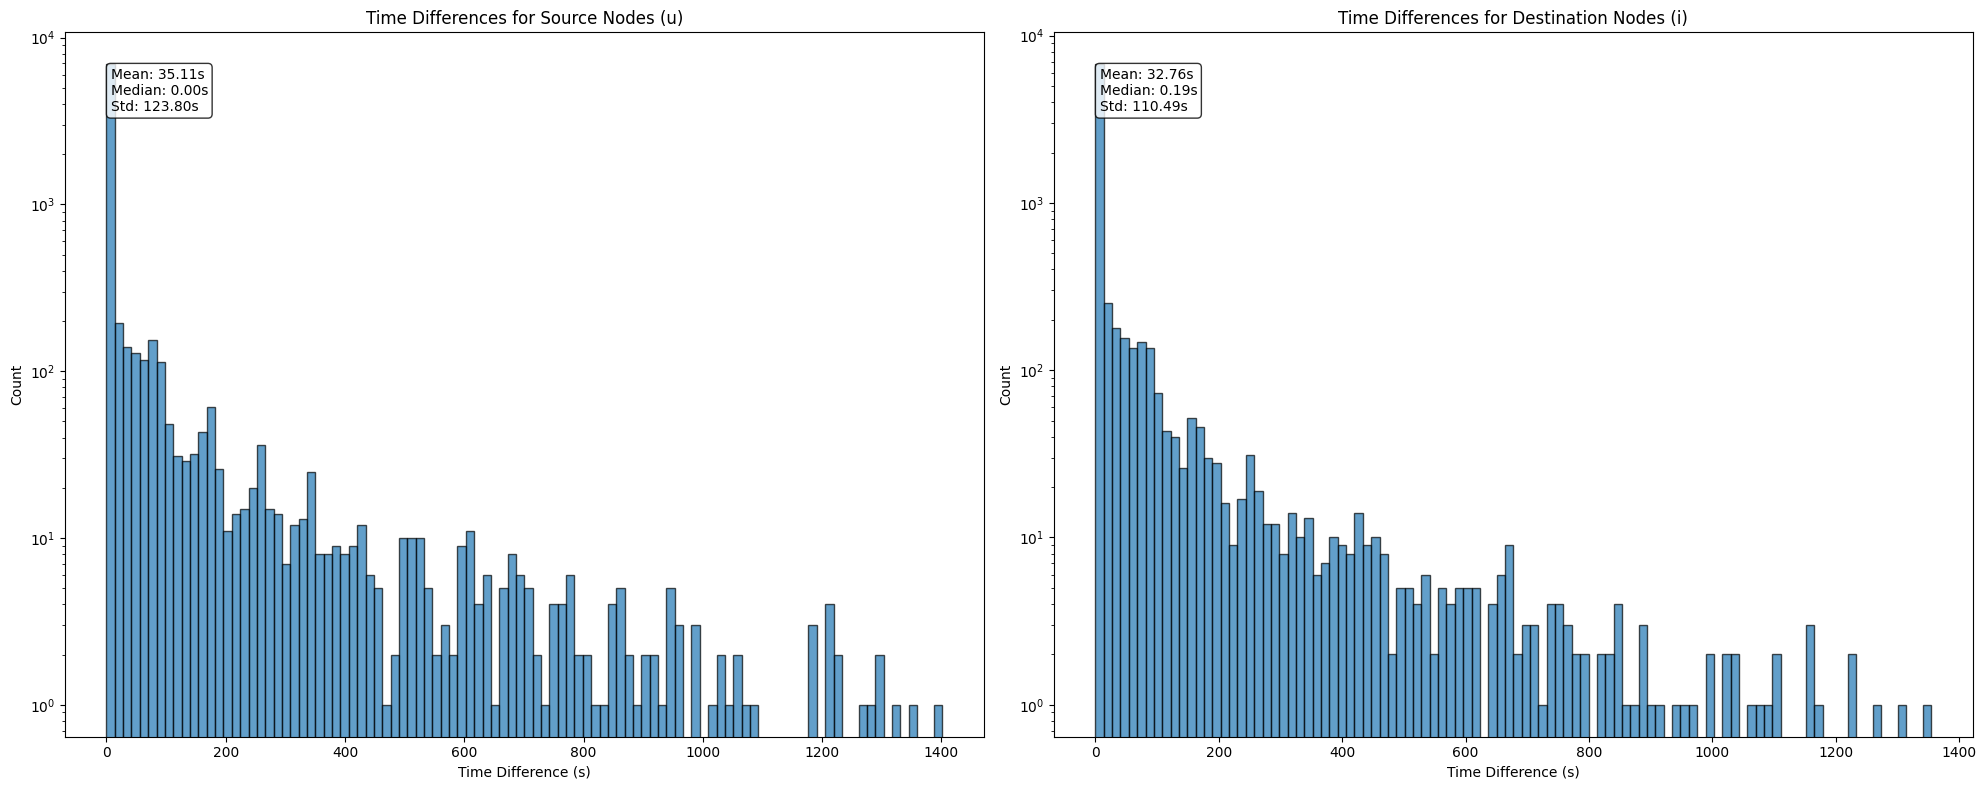

In [39]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [40]:
def check_c3_compliance(df, negative_samples, time_window=1200*1e3):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        window_start = max(ts - time_window, df_sorted['ts'].min())
        window_df = df_sorted[(df_sorted['ts'] >= window_start) & (df_sorted['ts'] <= ts)]
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

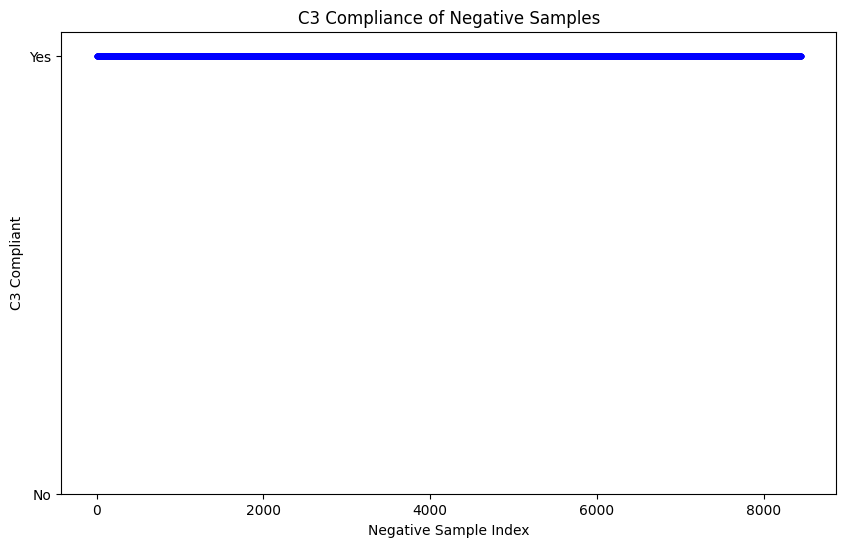

Percentage of C3 compliant samples: 100.00%


In [41]:
compliant = check_c3_compliance(missing_edges_df, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title('C3 Compliance of Negative Samples')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

print(f"Percentage of C3 compliant samples: {sum(compliant)/len(compliant)*100:.2f}%")

In [42]:
from collections import Counter

def compare_node_degrees(df1, df2, src_col='u', dst_col='i'):
    """
    Compare the degree distributions of source and destination nodes in two DataFrames.
    
    Args:
    df1, df2: pandas DataFrames to compare
    src_col: column name for source nodes (default 'u')
    dst_col: column name for destination nodes (default 'i')
    
    Returns:
    bool: True if both DataFrames have the same degree distributions, False otherwise
    """
    
    # Calculate degree distributions for df1
    src_degrees1 = Counter(df1[src_col])
    src_degrees1 = dict(sorted(src_degrees1.items(), key=lambda x: x[0]))
    dst_degrees1 = Counter(df1[dst_col])
    dst_degrees1 = dict(sorted(dst_degrees1.items(), key=lambda x: x[0]))
    
    # Calculate degree distributions for df2
    src_degrees2 = Counter(df2[src_col])
    src_degrees2 = dict(sorted(src_degrees2.items(), key=lambda x: x[0]))
    dst_degrees2 = Counter(df2[dst_col])
    dst_degrees2 = dict(sorted(dst_degrees2.items(), key=lambda x: x[0]))
    
    print(f"Total source degrees match: {sum(dict(src_degrees1).values()) == sum(dict(src_degrees2).values())}")
    print(f"Total destination degrees match: {sum(dict(dst_degrees1).values()) == sum(dict(dst_degrees2).values())}")
    
    src_keys = list(src_degrees1.keys())
    dst_keys = list(dst_degrees1.keys())
    
    for key in src_keys:
        if src_degrees1[key] != src_degrees2[key]:
            print(f'Degree do not match for {key}: {src_degrees1[key]} {src_degrees2[key]}')
    
    for key in dst_keys:
        if dst_degrees1[key] != dst_degrees2[key]:
            print(f'Degree do not match for {key}: {dst_degrees1[key]} {dst_degrees2[key]}')
    
    # Compare source node degrees
    if src_degrees1 != src_degrees2:
        print("Source node degrees do not match")
        return False
    
    # Compare destination node degrees
    if dst_degrees1 != dst_degrees2:
        print("Destination node degrees do not match")
        return False
    
    print("Both source and destination node degrees match")
    return True

# Usage
compare_node_degrees(missing_edges_df, ns_df)

Total source degrees match: True
Total destination degrees match: True
Both source and destination node degrees match


True

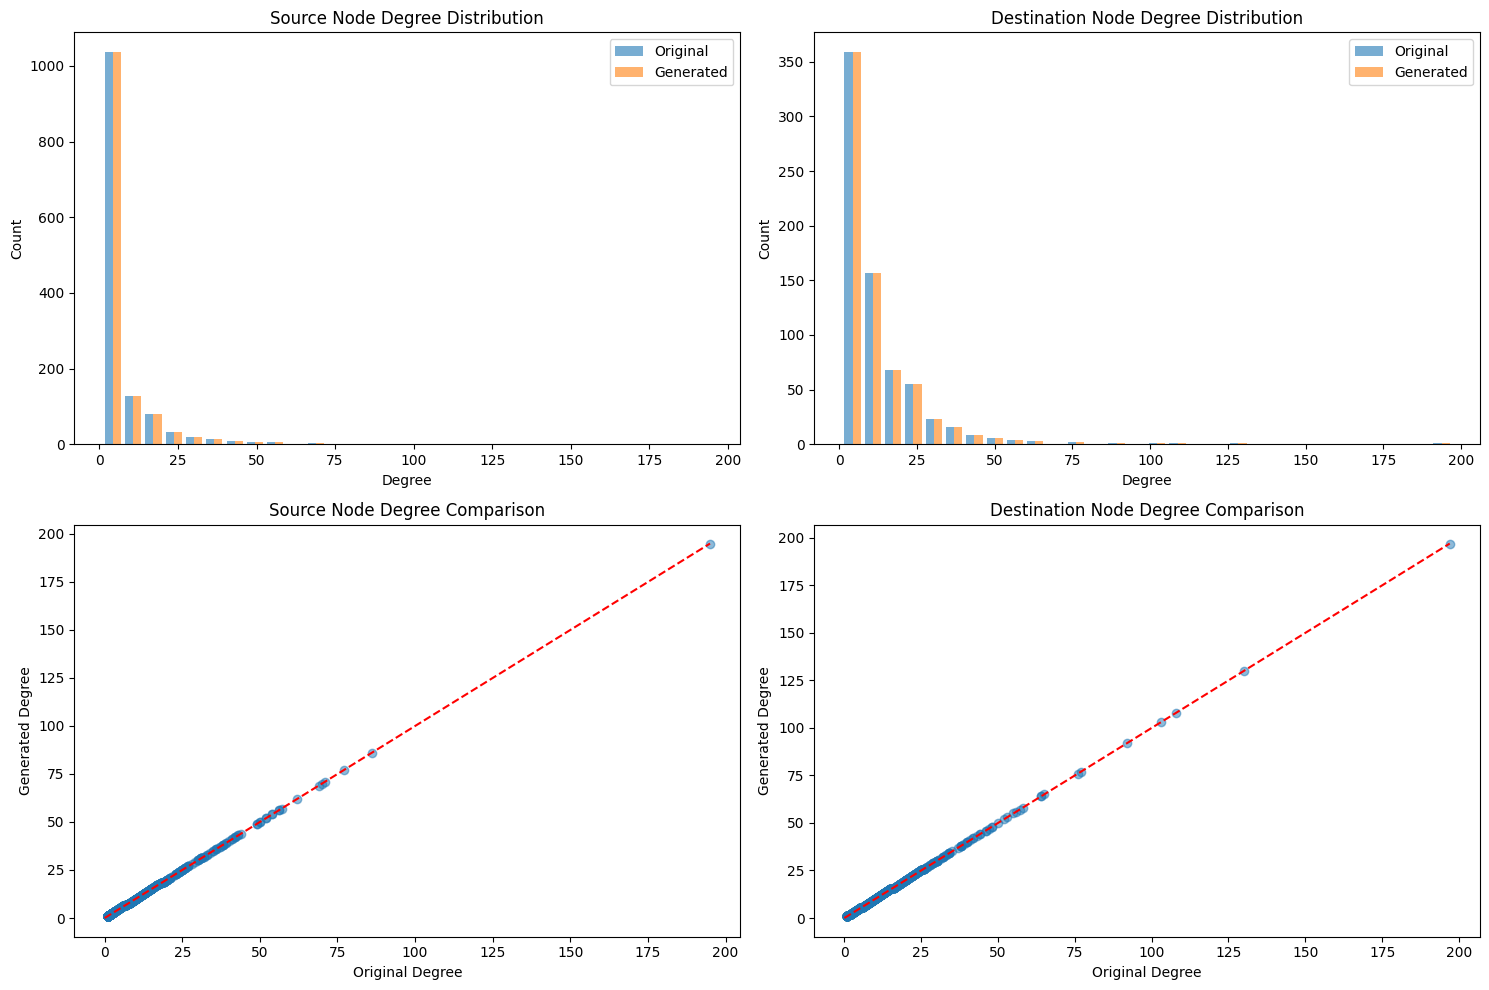

Source degree correlation: nan
Destination degree correlation: 1.000


/home/t2/miniconda3/envs/tgn2/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [43]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")
    

# use
plot_degree_comparison(missing_edges_df, ns_df)